In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

B_RESULTS_CSV_PATH = "B_results.csv"


#PHYSICAL CONSTRAINS
mu0 = 4 * np.pi * 1e-7  # T·m/A

# Experimental parameters
I_mA = 10.0
I_A = I_mA * 1e-3

NV_LAYER_THICKNESS_UM = 20.0
SENSOR_DEPTH_UM = NV_LAYER_THICKNESS_UM / 2.0  # use midpoint = 10 µm

# Corrected geometry convention
# x = horizontal magnet-to-magnet direction
# y = in-plane depth direction
# z = optical axis
WIRE_DIRECTION = "y"

# Wire center in the image plane
WIRE_X0_UM = 0.0
WIRE_Y0_UM = 0.0

B_COMPONENTS = ["Bx", "By", "Bz"]

In [22]:
# Load measured B_results.csv

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "pixel", "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"B_results.csv is missing columns: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not represent a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

Bx_pos_meas = B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size)
By_pos_meas = B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size)
Bz_pos_meas = B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size)

Bx_neg_meas = B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size)
By_neg_meas = B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size)
Bz_neg_meas = B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size)

B_pos_meas = np.stack([Bx_pos_meas, By_pos_meas, Bz_pos_meas], axis=0)
B_neg_meas = np.stack([Bx_neg_meas, By_neg_meas, Bz_neg_meas], axis=0)


## Infinite straight wire model

SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [23]:
# ============================================================
# Simulate infinite straight wire along y
# ============================================================

def simulate_infinite_wire_y(
    x_um,
    y_um,
    I_A,
    sensor_depth_um,
    wire_x0_um=0.0,
    wire_y0_um=0.0,
):
    """
    Infinite straight wire along +y.
    Wire lies on the surface z = 0.
    NV sensing depth is at z = -sensor_depth_um.

    Inputs:
        x_um, y_um : 2D coordinate grids [µm]
        I_A        : current [A]
        sensor_depth_um : distance below surface [µm]
        wire_x0_um, wire_y0_um : wire center coordinates [µm]

    Returns:
        B_nT with shape (3, Ny, Nx)
        order = [Bx, By, Bz]
    """

    x_m = (x_um - wire_x0_um) * 1e-6
    y_m = (y_um - wire_y0_um) * 1e-6  # not used explicitly for infinite wire
    z_m = -sensor_depth_um * 1e-6 * np.ones_like(x_m)

    rho2 = x_m**2 + z_m**2
    rho2 = np.where(rho2 < 1e-30, 1e-30, rho2)

    Bx_T = mu0 * I_A * z_m / (2 * np.pi * rho2)
    By_T = np.zeros_like(Bx_T)
    Bz_T = -mu0 * I_A * x_m / (2 * np.pi * rho2)

    B_nT = 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)
    return B_nT

In [24]:
# ============================================================
# Simulate +I and -I
# ============================================================

B_pos_sim = simulate_infinite_wire_y(
    x_grid_um,
    y_grid_um,
    I_A=+I_A,
    sensor_depth_um=SENSOR_DEPTH_UM,
    wire_x0_um=WIRE_X0_UM,
    wire_y0_um=WIRE_Y0_UM,
)

B_neg_sim = simulate_infinite_wire_y(
    x_grid_um,
    y_grid_um,
    I_A=-I_A,
    sensor_depth_um=SENSOR_DEPTH_UM,
    wire_x0_um=WIRE_X0_UM,
    wire_y0_um=WIRE_Y0_UM,
)

print("Simulated +I and -I maps")
for i, comp in enumerate(B_COMPONENTS):
    print(comp, "POS p95 [nT] =", np.nanpercentile(np.abs(B_pos_sim[i]), 95))

Simulated +I and -I maps
Bx POS p95 [nT] = 138461.5384615386
By POS p95 [nT] = 0.0
Bz POS p95 [nT] = 96000.0


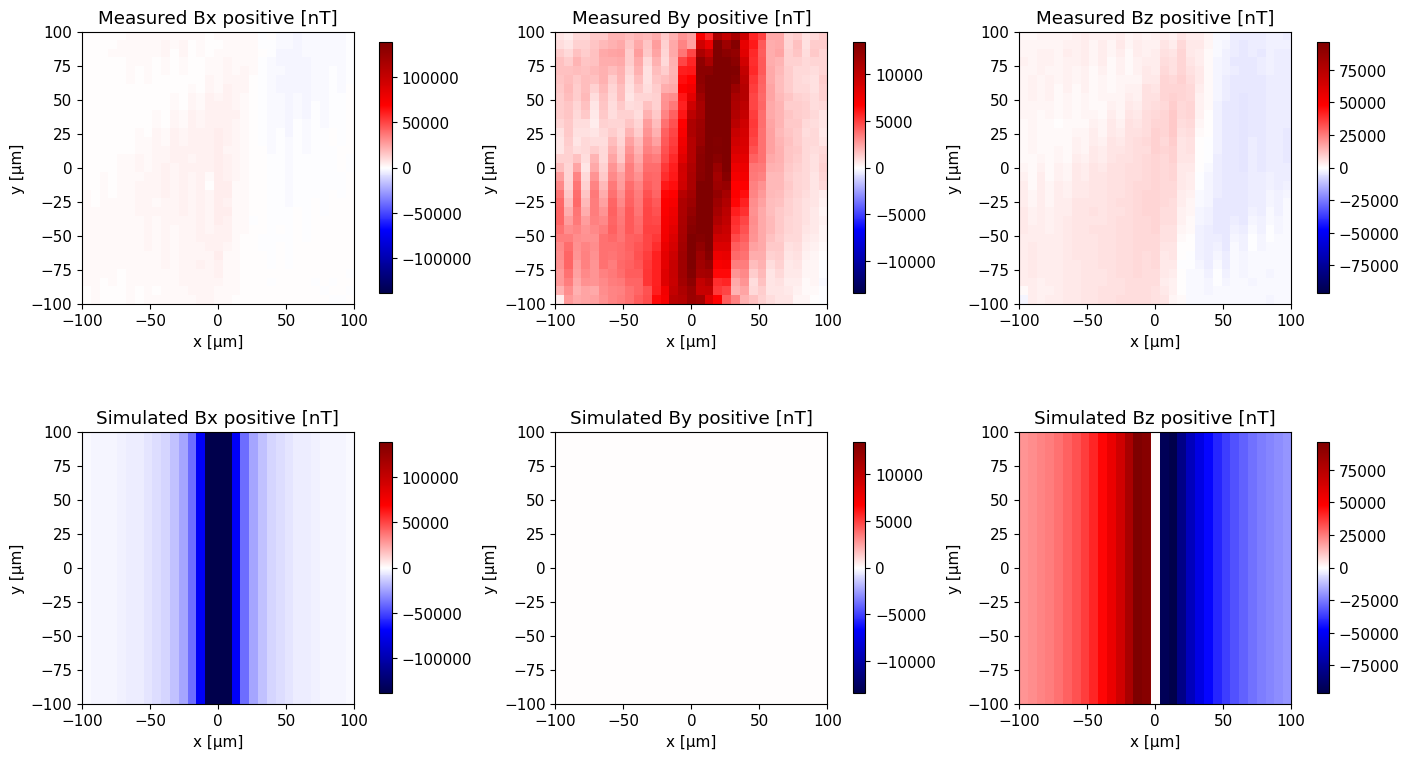

In [25]:
# ============================================================
# Plot measured POS vs simulated POS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_pos_sim[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_pos_sim[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Simulated {comp} positive [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()

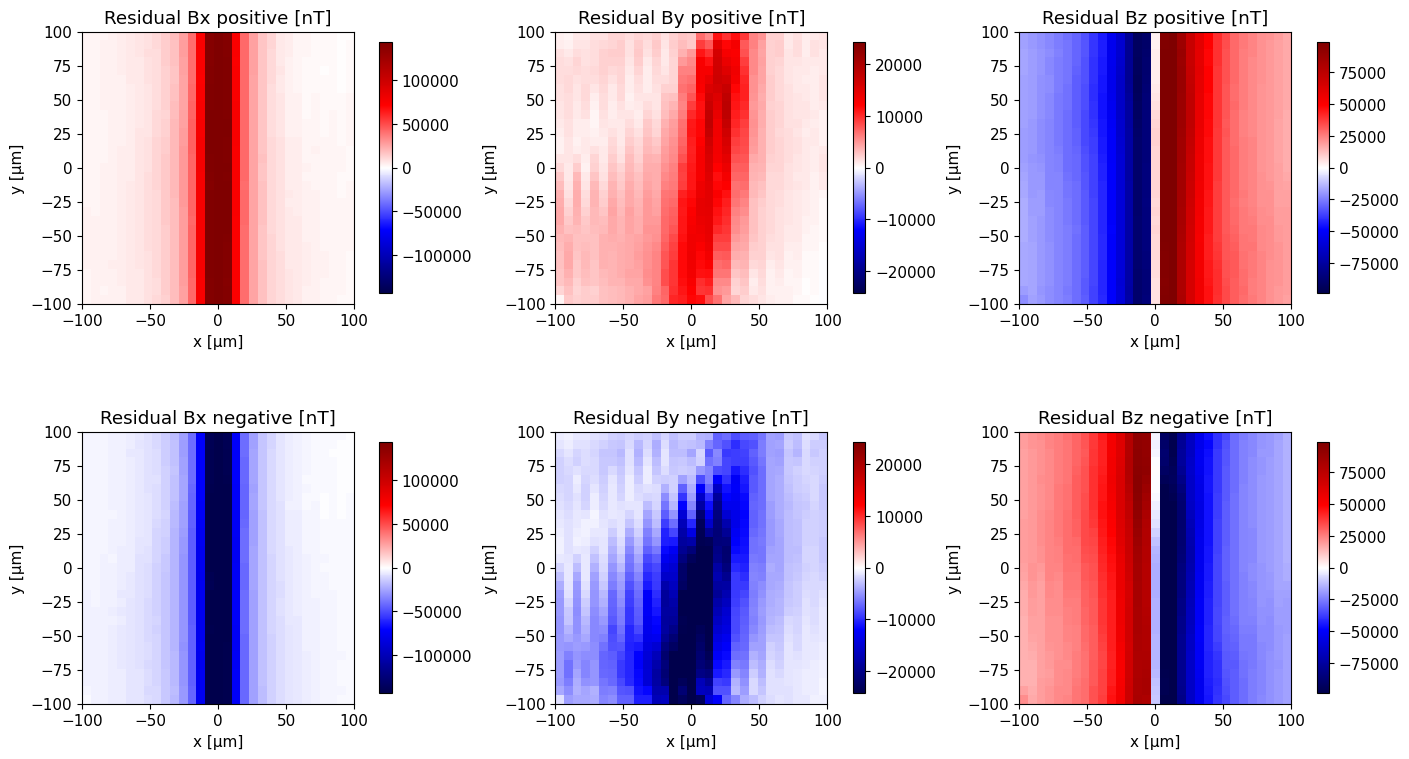

In [26]:
# ============================================================
# Residuals: measured - simulated
# ============================================================

B_pos_res = B_pos_meas - B_pos_sim
B_neg_res = B_neg_meas - B_neg_sim

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_res[i]), 95),
        np.nanpercentile(np.abs(B_neg_res[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_res[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Residual {comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_neg_res[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Residual {comp} negative [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()

In [27]:
# ============================================================
# Simulation diagnostic:
# component alignment, sign, and scale comparison
# ============================================================
# Goal:
#   Check whether measured Bx, By, Bz are aligned with simulated Bx, By, Bz,
#   or whether a component swap/sign flip is likely.
#
# This does NOT modify data. It only prints diagnostics.
# ============================================================

import itertools
import numpy as np
import pandas as pd

# Current-odd and current-even measured fields
B_meas_odd = 0.5 * (B_pos_meas - B_neg_meas)
B_meas_even = 0.5 * (B_pos_meas + B_neg_meas)

# Current-odd simulated field
B_sim_odd = 0.5 * (B_pos_sim - B_neg_sim)

def fit_scale_and_corr(meas, sim):
    """
    Return best scalar scale, correlation, and normalized RMS residual.
    meas, sim are 1D arrays.
    """
    mask = np.isfinite(meas) & np.isfinite(sim)
    meas = meas[mask]
    sim = sim[mask]

    if len(meas) < 3 or np.nanstd(sim) == 0 or np.nanstd(meas) == 0:
        return np.nan, np.nan, np.nan

    scale = np.sum(meas * sim) / np.sum(sim**2)
    sim_scaled = scale * sim

    corr = np.corrcoef(meas, sim)[0, 1]

    rms_res = np.sqrt(np.mean((meas - sim_scaled)**2))
    rms_meas = np.sqrt(np.mean(meas**2))

    nrmse = rms_res / rms_meas if rms_meas != 0 else np.nan

    return scale, corr, nrmse


# ------------------------------------------------------------
# 1. Direct component comparison
# ------------------------------------------------------------

rows = []

for i_meas, meas_comp in enumerate(B_COMPONENTS):
    for i_sim, sim_comp in enumerate(B_COMPONENTS):
        meas = B_meas_odd[i_meas].ravel()
        sim = B_sim_odd[i_sim].ravel()

        scale, corr, nrmse = fit_scale_and_corr(meas, sim)

        rows.append({
            "measured_component": meas_comp,
            "simulated_component": sim_comp,
            "best_scale_meas_over_sim": scale,
            "corr": corr,
            "abs_corr": abs(corr) if np.isfinite(corr) else np.nan,
            "normalized_RMSE_after_scaling": nrmse,
        })

component_match_df = pd.DataFrame(rows).sort_values(
    ["abs_corr", "normalized_RMSE_after_scaling"],
    ascending=[False, True]
)

print("Direct measured-component vs simulated-component comparison")
display(component_match_df)


# ------------------------------------------------------------
# 2. Test all component permutations
# ------------------------------------------------------------

perm_rows = []

for perm in itertools.permutations(range(3)):
    # perm means:
    # measured Bx compared to sim component perm[0],
    # measured By compared to sim component perm[1],
    # measured Bz compared to sim component perm[2]
    sim_perm = B_sim_odd[list(perm)]

    meas_flat = B_meas_odd.reshape(3, -1).ravel()
    sim_flat = sim_perm.reshape(3, -1).ravel()

    scale, corr, nrmse = fit_scale_and_corr(meas_flat, sim_flat)

    perm_rows.append({
        "mapping": f"meas [Bx,By,Bz] <- sim [{B_COMPONENTS[perm[0]]},{B_COMPONENTS[perm[1]]},{B_COMPONENTS[perm[2]]}]",
        "perm_indices": perm,
        "best_scale_meas_over_sim": scale,
        "corr": corr,
        "abs_corr": abs(corr) if np.isfinite(corr) else np.nan,
        "normalized_RMSE_after_scaling": nrmse,
    })

perm_df = pd.DataFrame(perm_rows).sort_values(
    ["abs_corr", "normalized_RMSE_after_scaling"],
    ascending=[False, True]
)

print("Best component permutations")
display(perm_df)


# ------------------------------------------------------------
# 3. Amplitude scale check
# ------------------------------------------------------------

amp_rows = []

for i, comp in enumerate(B_COMPONENTS):
    amp_rows.append({
        "component": comp,
        "meas_pos_p95_abs_nT": np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        "meas_neg_p95_abs_nT": np.nanpercentile(np.abs(B_neg_meas[i]), 95),
        "meas_odd_p95_abs_nT": np.nanpercentile(np.abs(B_meas_odd[i]), 95),
        "meas_even_p95_abs_nT": np.nanpercentile(np.abs(B_meas_even[i]), 95),
        "sim_pos_p95_abs_nT": np.nanpercentile(np.abs(B_pos_sim[i]), 95),
        "sim_odd_p95_abs_nT": np.nanpercentile(np.abs(B_sim_odd[i]), 95),
    })

amp_df = pd.DataFrame(amp_rows)

print("Amplitude comparison")
display(amp_df)


# ------------------------------------------------------------
# 4. POS/NEG anti-symmetry check in measured data
# ------------------------------------------------------------

antisym_rows = []

for i, comp in enumerate(B_COMPONENTS):
    pos = B_pos_meas[i].ravel()
    neg = B_neg_meas[i].ravel()

    mask = np.isfinite(pos) & np.isfinite(neg)

    corr_pos_neg = np.corrcoef(pos[mask], neg[mask])[0, 1]
    corr_pos_minus_neg = np.corrcoef(pos[mask], -neg[mask])[0, 1]

    p95_pos = np.nanpercentile(np.abs(pos), 95)
    p95_neg = np.nanpercentile(np.abs(neg), 95)

    antisym_rows.append({
        "component": comp,
        "corr(pos, neg)": corr_pos_neg,
        "corr(pos, -neg)": corr_pos_minus_neg,
        "p95_neg_over_pos": p95_neg / p95_pos if p95_pos != 0 else np.nan,
    })

antisym_df = pd.DataFrame(antisym_rows)

print("Measured POS/NEG antisymmetry check")
display(antisym_df)

Direct measured-component vs simulated-component comparison


,measured_component,simulated_component,best_scale_meas_over_sim,corr,abs_corr,normalized_RMSE_after_scaling
3,By,Bx,-0.111712,-0.660971,0.660971,0.645479
0,Bx,Bx,-0.027129,-0.584187,0.584187,0.710376
6,Bz,Bx,-0.057881,-0.536894,0.536894,0.775446
8,Bz,Bz,0.039126,0.437919,0.437919,0.916835
2,Bx,Bz,0.013932,0.408000,0.408000,0.941100
5,By,Bz,-0.022432,-0.211537,0.211537,0.989655
1,Bx,By,NaN,NaN,NaN,NaN
4,By,By,NaN,NaN,NaN,NaN
7,Bz,By,NaN,NaN,NaN,NaN


Best component permutations


,mapping,perm_indices,best_scale_meas_over_sim,corr,abs_corr,normalized_RMSE_after_scaling
4,"meas [Bx,By,Bz] <- sim [Bz,Bx,By]","(2, 0, 1)",-0.053075,-0.356913,0.356913,0.911673
3,"meas [Bx,By,Bz] <- sim [By,Bz,Bx]","(1, 2, 0)",-0.041337,-0.245925,0.245925,0.947403
2,"meas [Bx,By,Bz] <- sim [By,Bx,Bz]","(1, 0, 2)",-0.041317,-0.245735,0.245735,0.947455
0,"meas [Bx,By,Bz] <- sim [Bx,By,Bz]","(0, 1, 2)",0.003791,0.180813,0.180813,0.999569
1,"meas [Bx,By,Bz] <- sim [Bx,Bz,By]","(0, 2, 1)",-0.024937,-0.090842,0.090842,0.981185
5,"meas [Bx,By,Bz] <- sim [Bz,By,Bx]","(2, 1, 0)",-0.024366,-0.085448,0.085448,0.982044


Amplitude comparison


,component,meas_pos_p95_abs_nT,meas_neg_p95_abs_nT,meas_odd_p95_abs_nT,meas_even_p95_abs_nT,sim_pos_p95_abs_nT,sim_odd_p95_abs_nT
0,Bx,3673.775926,5308.921674,4389.325217,965.983440,138461.538462,138461.538462
1,By,13433.715458,24199.039111,18013.089288,6267.131307,0.000000,0.000000
2,Bz,7395.124461,13584.200572,10305.770183,3633.502009,96000.000000,96000.000000


Measured POS/NEG antisymmetry check


,component,"corr(pos, neg)","corr(pos, -neg)",p95_neg_over_pos
0,Bx,-0.935002,0.935002,1.445086
1,By,-0.839223,0.839223,1.801366
2,Bz,-0.895024,0.895024,1.836913
